# Machine Failure Analysis — Exploratory Data Analysis
### AI4I 2020 Predictive Maintenance Dataset

**Contents**
1. Setup & Imports  
2. Data Loading  
3. Dataset Overview  
4. Data Quality Assessment  
5. Descriptive Statistics  
6. Correlation Analysis  
7. Feature Distributions  
8. Machine Failure Analysis  
9. Machine Type Analysis  
10. RPM Analysis  
11. Tool Wear Analysis  
12. Failure Mode Deep Dive  
13. Final Conclusions  


## 1. Setup & Imports

Importing only the libraries needed for this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE = ['#1a6eb5', '#d94f3b', '#2c9e6e', '#d97706', '#7c3aed']
sns.set_palette(PALETTE)
print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading

Loading the CSV and performing a quick sanity check.

In [2]:
df = pd.read_csv('../ai4i2020.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (10000, 14)
Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Dataset Overview

Basic structural information about the dataset.

In [3]:
print('=' * 50)
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print('=' * 50)
print('\nColumns:')
for col in df.columns:
    print(f'  {col}')

Rows    : 10,000
Columns : 14

Columns:
  UDI
  Product ID
  Type
  Air temperature [K]
  Process temperature [K]
  Rotational speed [rpm]
  Torque [Nm]
  Tool wear [min]
  Machine failure
  TWF
  HDF
  PWF
  OSF
  RNF


In [4]:
df.dtypes.to_frame(name='Data Type')

,Data Type
UDI,int64
Product ID,str
Type,str
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64


## 4. Data Quality Assessment

Checking for missing values and duplicate records before proceeding.

In [5]:
missing = df.isnull().sum().rename('Missing Count')
missing_pct = (missing / len(df) * 100).rename('Missing %')
pd.concat([missing, missing_pct], axis=1)

,Missing Count,Missing %
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


In [6]:
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')

if n_dupes > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Removed duplicates. New shape: {df.shape}')
else:
    print('No duplicates detected — dataset is clean.')

Duplicate rows found: 0
No duplicates detected — dataset is clean.


**Observation:** The dataset has no missing values and no duplicate rows. As a synthetically generated dataset, it was designed to be clean from the outset. No imputation or row removal is required.

In [7]:
import io
buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

## 5. Descriptive Statistics

Numerical summary of the five continuous process variables.

In [8]:
num_cols = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]
df[num_cols].describe().round(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.0,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95
std,2.0,1.48,179.28,9.97,63.65
min,295.3,305.70,1168.00,3.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.80,162.00
max,304.5,313.80,2886.00,76.60,253.00


**Observation:** Air and Process temperatures are narrow-ranged (~295–315 K), reflecting controlled conditions. Rotational speed is roughly normally distributed around 1,539 rpm. Torque spans ~3.8–76.6 Nm. Tool wear covers the full lifecycle from 0 to 253 minutes.

In [9]:
print('Machine Type Distribution:')
print(df['Type'].value_counts())
print()
print('Machine Failure Distribution:')
print(df['Machine failure'].value_counts())
print()
print(f"Failure Rate: {df['Machine failure'].mean() * 100:.2f}%")

Machine Type Distribution:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Machine Failure Distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure Rate: 3.39%


## 6. Correlation Analysis

Pearson correlation matrix to identify linear relationships between features and the failure target.

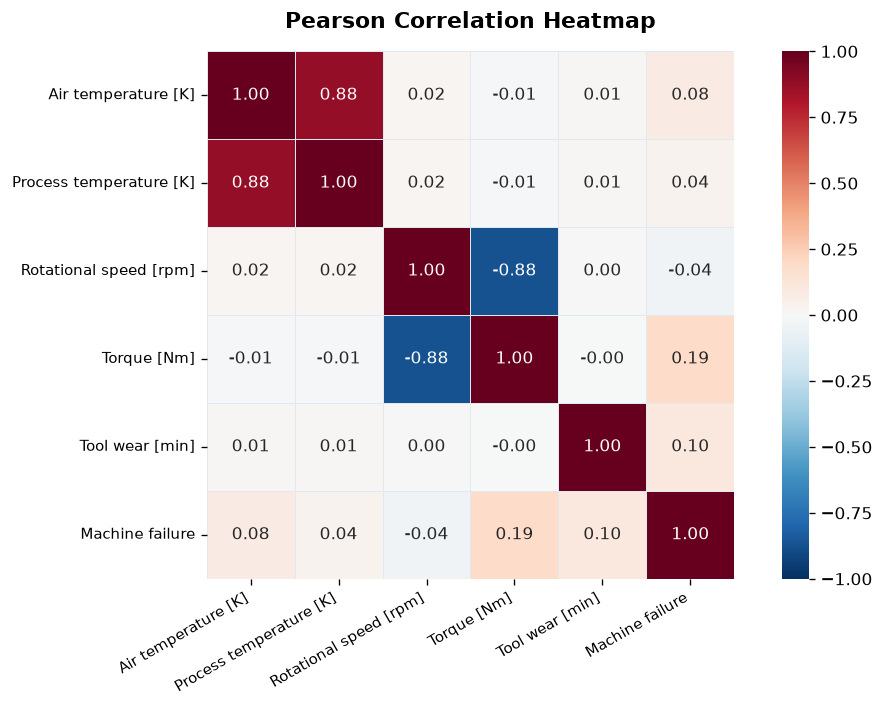

In [10]:
corr_cols = num_cols + ['Machine failure']
corr_matrix = df[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='#e2e8f0',
    square=True,
    ax=ax,
)
ax.set_title('Pearson Correlation Heatmap', pad=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** Air temperature and Process temperature are strongly correlated (r ≈ 0.88). Rotational speed and Torque have a strong negative correlation (r ≈ −0.88), consistent with constant-power mechanics. Tool wear has a modest positive correlation with machine failure.

## 7. Feature Distributions

Histograms and boxplots for each numerical feature.

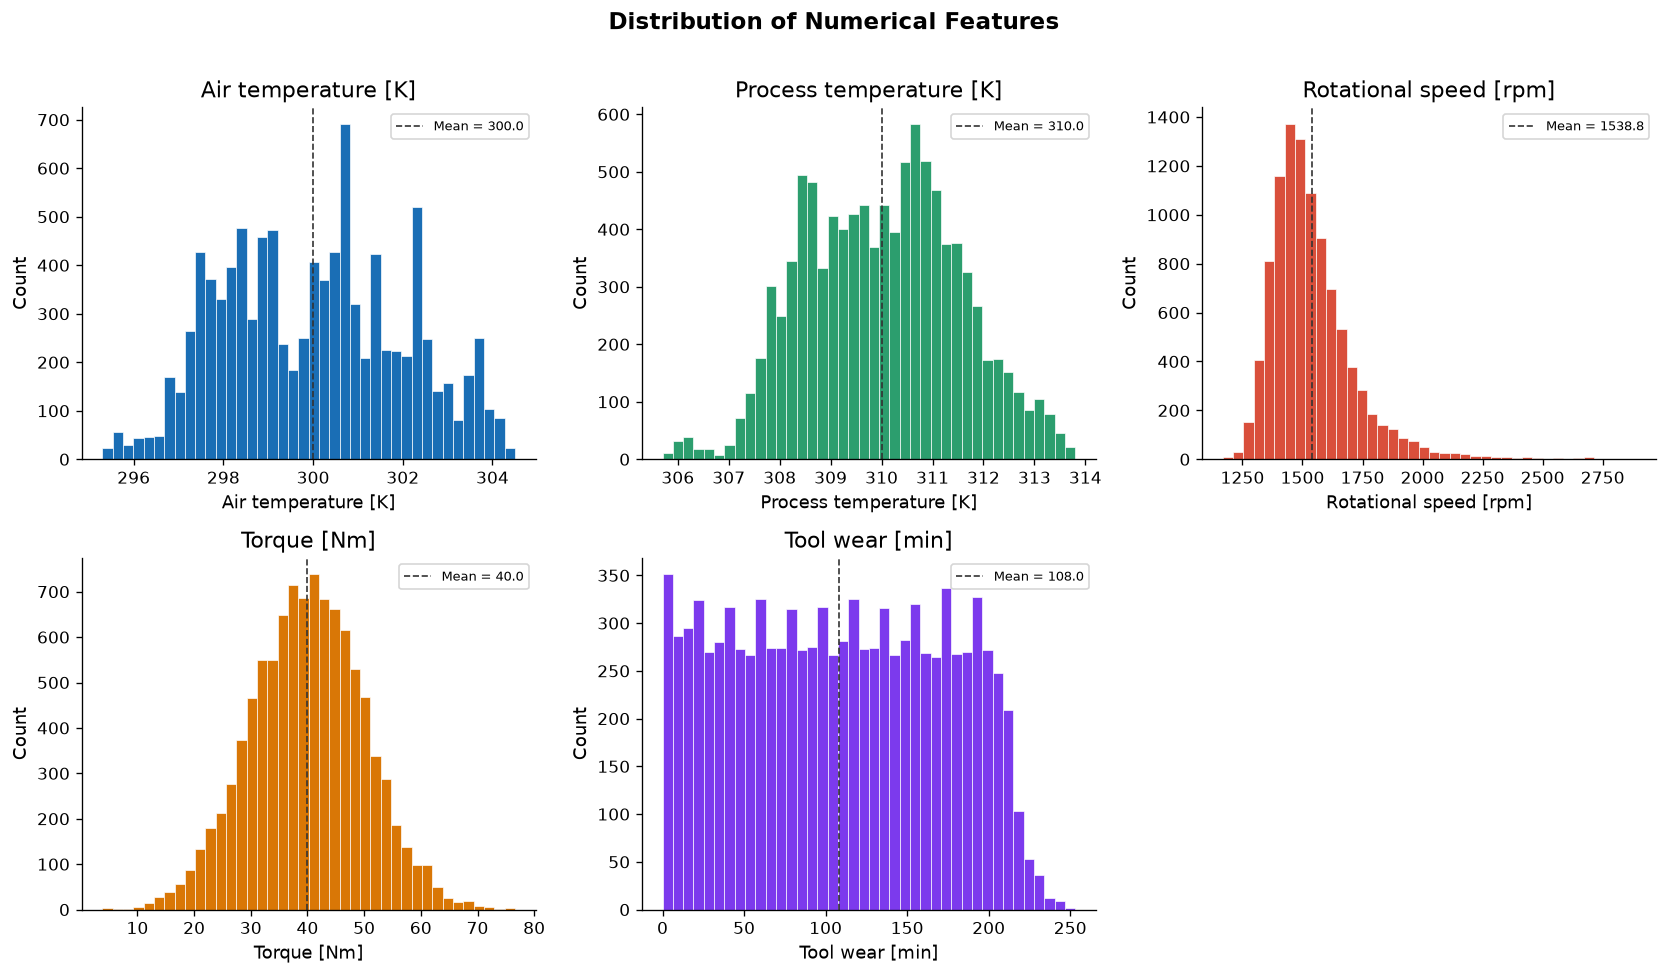

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

configs = [
    ('Air temperature [K]',      PALETTE[0]),
    ('Process temperature [K]',  PALETTE[2]),
    ('Rotational speed [rpm]',   PALETTE[1]),
    ('Torque [Nm]',              PALETTE[3]),
    ('Tool wear [min]',          PALETTE[4]),
]

for i, (col, color) in enumerate(configs):
    axes[i].hist(df[col], bins=40, color=color, edgecolor='white', linewidth=0.4)
    axes[i].axvline(df[col].mean(), color='#333', linestyle='--', linewidth=1,
                    label=f'Mean = {df[col].mean():.1f}')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observation:** Temperature features are approximately normally distributed. Rotational speed is slightly right-skewed. Torque is roughly bell-shaped. Tool wear is nearly uniform — the dataset deliberately covers the full wear lifecycle.

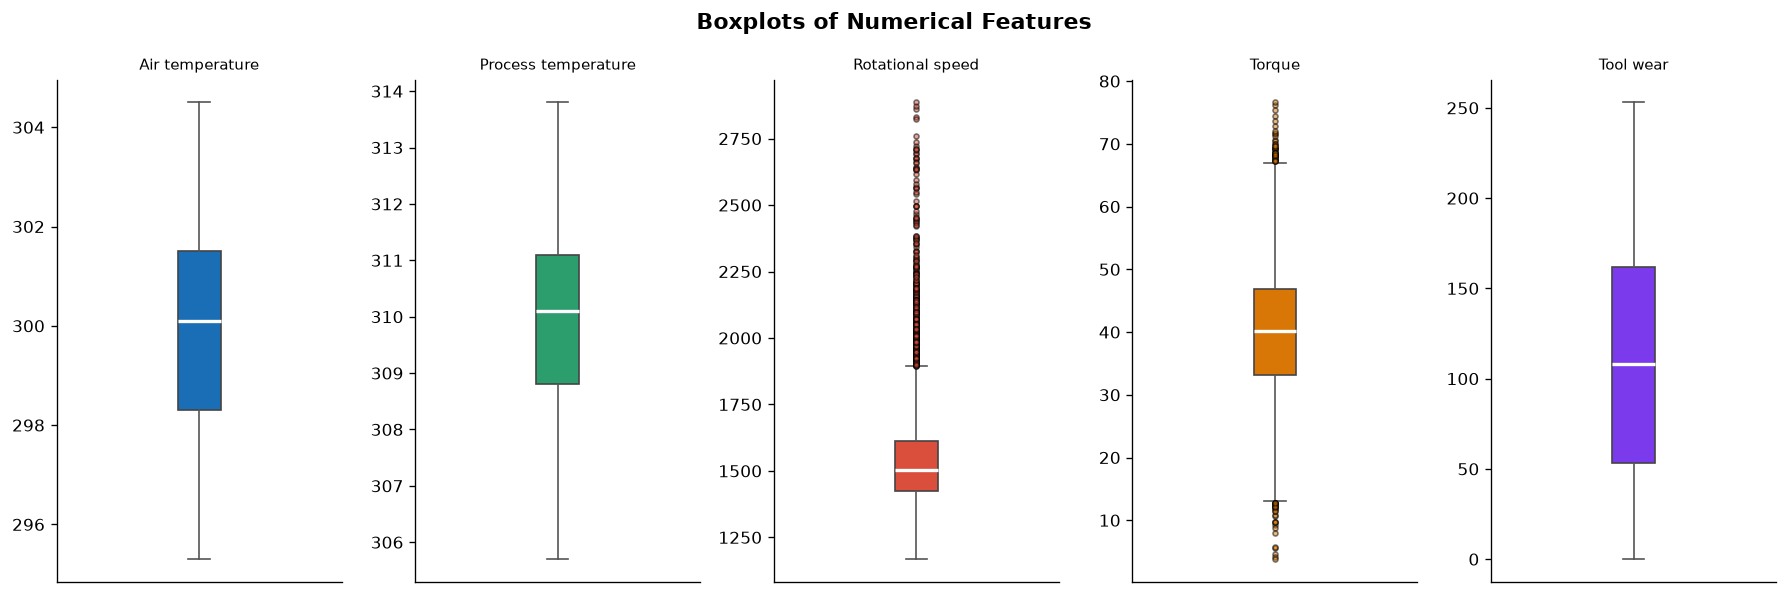

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, (col, color) in enumerate(configs):
    bp = axes[i].boxplot(
        df[col], patch_artist=True,
        boxprops=dict(facecolor=color, color='#444'),
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(color='#555'),
        capprops=dict(color='#555'),
        flierprops=dict(marker='o', markerfacecolor=color, markersize=3, alpha=0.5),
    )
    axes[i].set_title(col.split(' [')[0], fontsize=9)
    axes[i].set_xticks([])

fig.suptitle('Boxplots of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Rotational speed has notable high-end outliers, indicating some machines run at extreme speeds. Torque is well-contained. Temperature features show minimal spread, confirming stable thermal control.

## 8. Machine Failure Analysis

Overall failure distribution and breakdown across machine types.

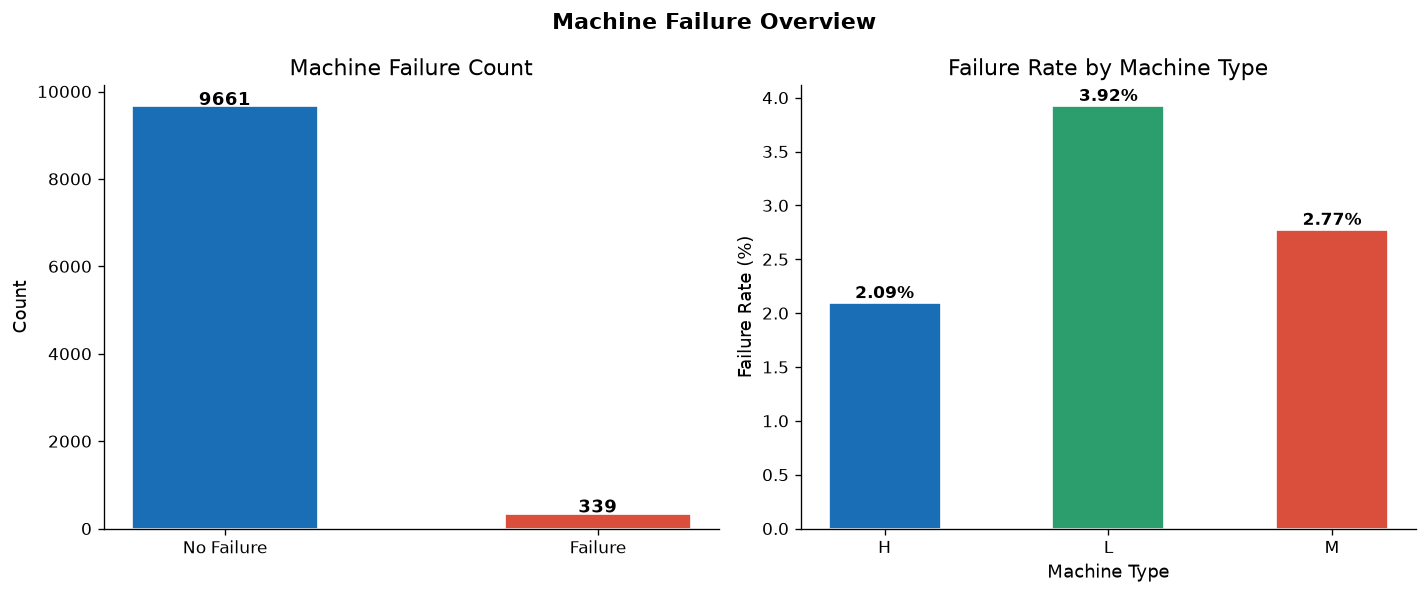

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Failure count bar chart
labels = ['No Failure', 'Failure']
vals   = [int((df['Machine failure'] == 0).sum()), int((df['Machine failure'] == 1).sum())]
bars = axes[0].bar(labels, vals, color=[PALETTE[0], PALETTE[1]], width=0.5, edgecolor='white')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 30,
                 str(v), ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Machine Failure Count')
axes[0].set_ylabel('Count')

# Failure rate by machine type
rate_df = (
    df.groupby('Type')['Machine failure']
    .agg(failures='sum', total='count')
    .assign(rate=lambda x: (x['failures'] / x['total'] * 100).round(2))
    .reset_index()
)
type_colors = [PALETTE[0], PALETTE[2], PALETTE[1]]
bars2 = axes[1].bar(rate_df['Type'], rate_df['rate'],
                    color=type_colors, width=0.5, edgecolor='white')
for bar, v in zip(bars2, rate_df['rate']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.05,
                 f'{v}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Failure Rate by Machine Type')
axes[1].set_xlabel('Machine Type')
axes[1].set_ylabel('Failure Rate (%)')

fig.suptitle('Machine Failure Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The dataset is heavily imbalanced (~3.4% failures). High-grade (H) machines have the highest failure rate percentage, suggesting more demanding operating conditions despite being fewer in count.

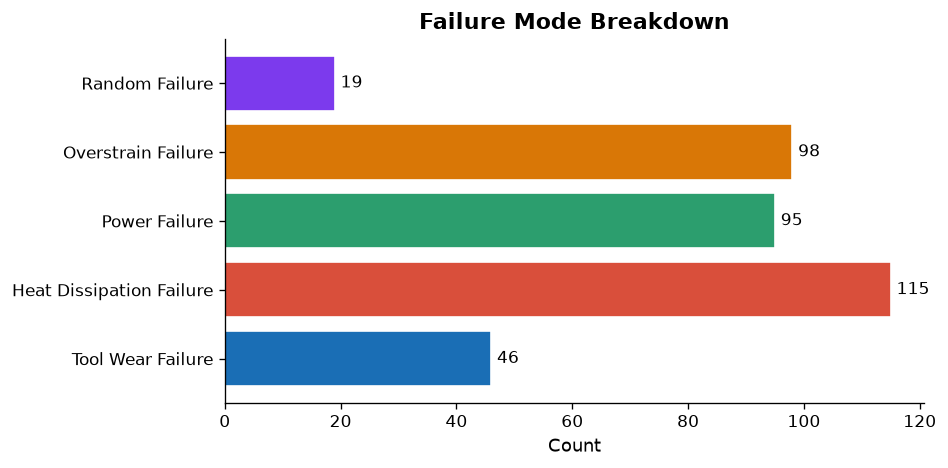

In [14]:
mode_map = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure',
}
mode_counts = df[list(mode_map.keys())].sum().rename(index=mode_map)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(mode_counts.index, mode_counts.values,
               color=PALETTE[:5], edgecolor='white')
for bar, v in zip(bars, mode_counts.values):
    ax.text(v + 1, bar.get_y() + bar.get_height() / 2,
            str(v), va='center', fontsize=10)
ax.set_title('Failure Mode Breakdown', fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

**Observation:** Heat Dissipation Failure (HDF) and Overstrain Failure (OSF) are the most frequent. Random Failure (RNF) is the rarest (<20 cases), as expected for unpredictable failures.

## 9. Machine Type Analysis

Composition of machine types and process parameter differences across quality grades.

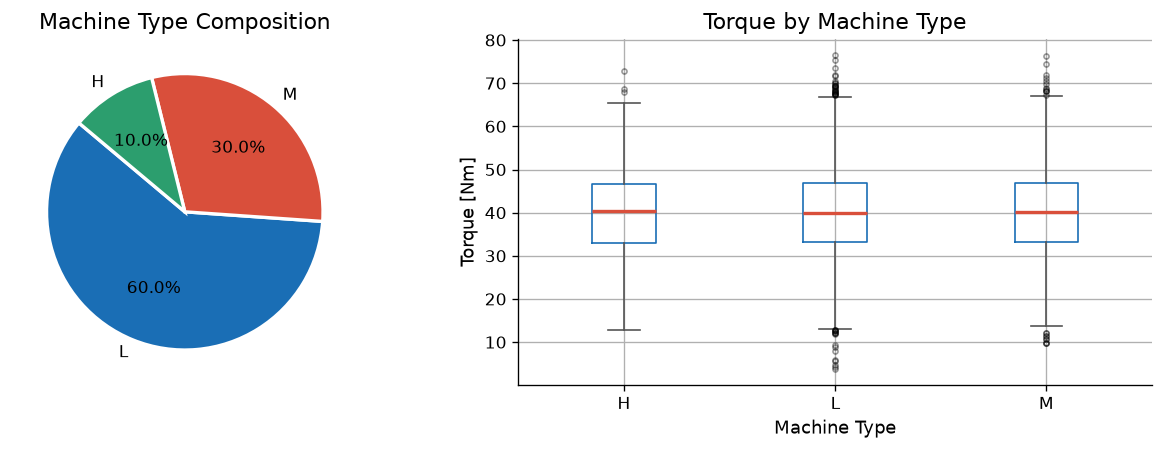

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

type_counts = df['Type'].value_counts()
axes[0].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=PALETTE[:3],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)
axes[0].set_title('Machine Type Composition')

df.boxplot(
    column='Torque [Nm]', by='Type', ax=axes[1],
    boxprops=dict(color=PALETTE[0]),
    medianprops=dict(color=PALETTE[1], linewidth=2),
    whiskerprops=dict(color='#555'),
    capprops=dict(color='#555'),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
)
axes[1].set_title('Torque by Machine Type')
axes[1].set_xlabel('Machine Type')
axes[1].set_ylabel('Torque [Nm]')
plt.suptitle('')

plt.tight_layout()
plt.show()

**Observation:** ~60% of machines are Low-grade (L), ~30% Medium (M), ~10% High (H). Torque distributions are similar across types, suggesting standardized load settings in this simulation.

## 10. Rotational Speed (RPM) Analysis

Distribution of rotational speed and its interaction with machine failures.

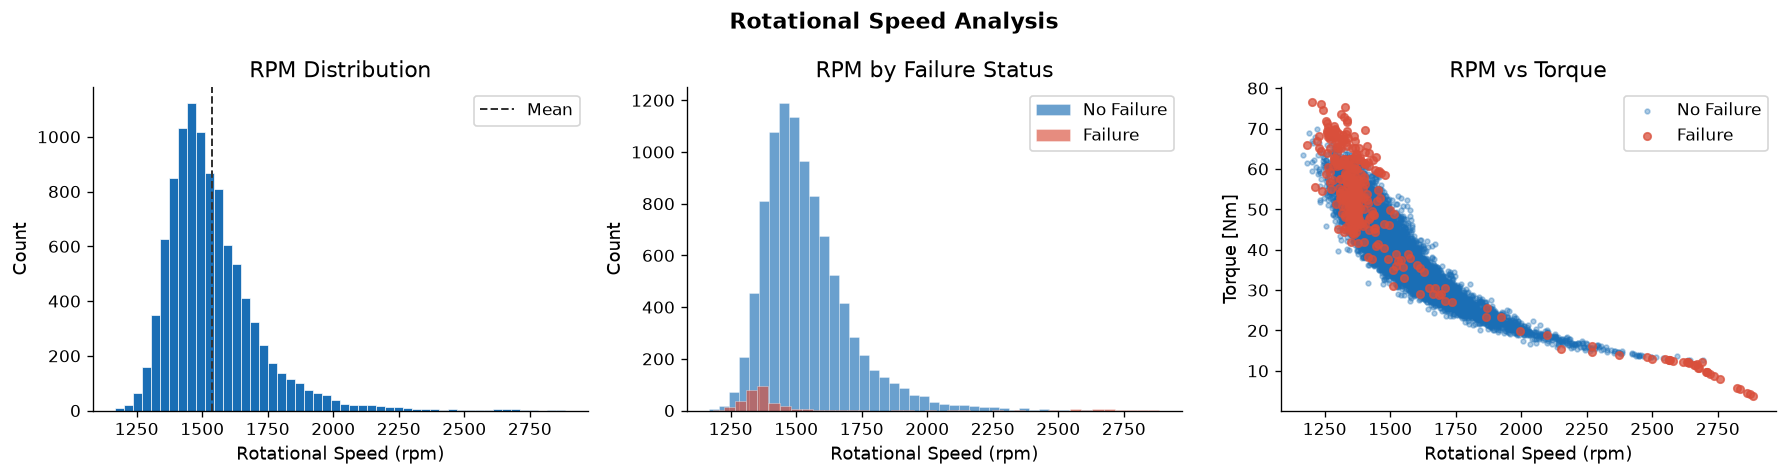

In [16]:
no_fail = df[df['Machine failure'] == 0]
failed  = df[df['Machine failure'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['Rotational speed [rpm]'], bins=50,
             color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].axvline(df['Rotational speed [rpm]'].mean(),
                color='#333', linestyle='--', linewidth=1.2, label='Mean')
axes[0].set_title('RPM Distribution')
axes[0].set_xlabel('Rotational Speed (rpm)')
axes[0].set_ylabel('Count')
axes[0].legend()

# RPM by failure status
for data, label, color in [(no_fail, 'No Failure', PALETTE[0]), (failed, 'Failure', PALETTE[1])]:
    axes[1].hist(data['Rotational speed [rpm]'], bins=40,
                 alpha=0.65, color=color, label=label,
                 edgecolor='white', linewidth=0.3)
axes[1].set_title('RPM by Failure Status')
axes[1].set_xlabel('Rotational Speed (rpm)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Scatter: RPM vs Torque
axes[2].scatter(no_fail['Rotational speed [rpm]'], no_fail['Torque [Nm]'],
                s=8, alpha=0.35, color=PALETTE[0], label='No Failure')
axes[2].scatter(failed['Rotational speed [rpm]'], failed['Torque [Nm]'],
                s=20, alpha=0.75, color=PALETTE[1], label='Failure')
axes[2].set_title('RPM vs Torque')
axes[2].set_xlabel('Rotational Speed (rpm)')
axes[2].set_ylabel('Torque [Nm]')
axes[2].legend()

fig.suptitle('Rotational Speed Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** RPM is approximately normally distributed around 1,539 rpm. Failures cluster at the extremes of the RPM range. The RPM vs Torque scatter reveals a clear inverse relationship; failures appear near the boundary of the operational envelope — particularly at high torque and low speed.

## 11. Tool Wear Analysis

How tool degradation progresses and where failures tend to occur along the wear lifecycle.

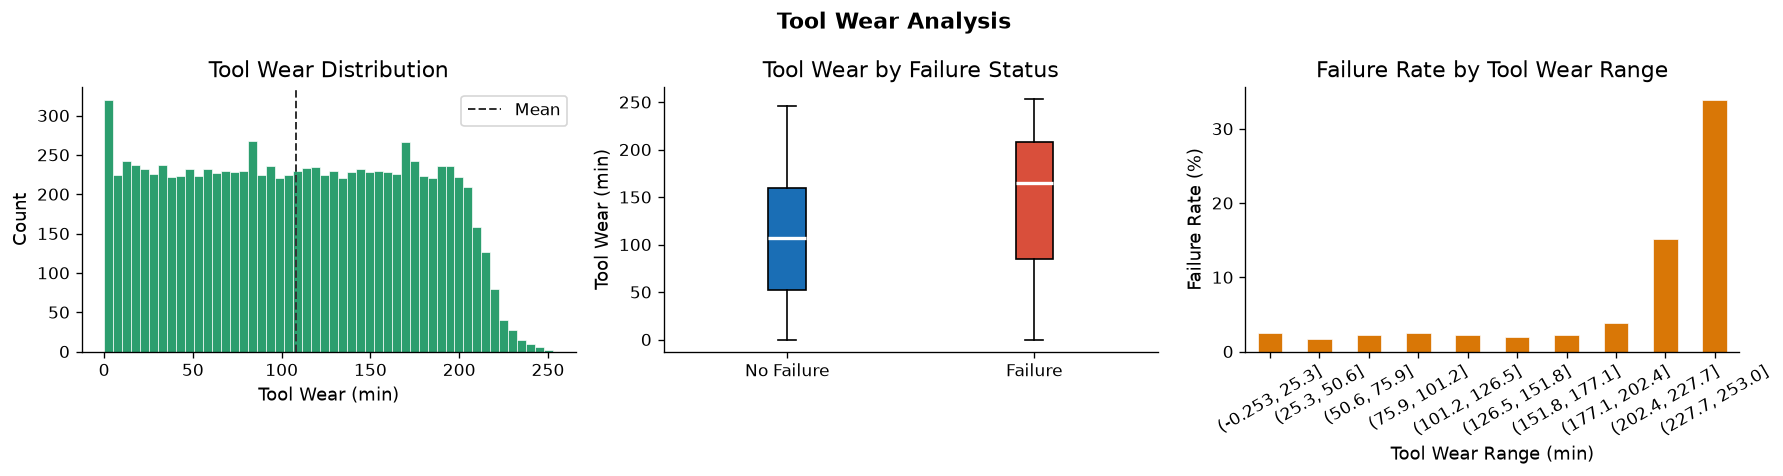

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tool wear histogram
axes[0].hist(df['Tool wear [min]'], bins=50,
             color=PALETTE[2], edgecolor='white', linewidth=0.4)
axes[0].axvline(df['Tool wear [min]'].mean(),
                color='#333', linestyle='--', linewidth=1.2, label='Mean')
axes[0].set_title('Tool Wear Distribution')
axes[0].set_xlabel('Tool Wear (min)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot by failure status
groups = [no_fail['Tool wear [min]'], failed['Tool wear [min]']]
bp = axes[1].boxplot(groups, tick_labels=['No Failure', 'Failure'], patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[1]]):
    patch.set_facecolor(color)
axes[1].set_title('Tool Wear by Failure Status')
axes[1].set_ylabel('Tool Wear (min)')

# Failure rate per wear bin
df_tmp = df.copy()
df_tmp['Wear Bin'] = pd.cut(df_tmp['Tool wear [min]'], bins=10)
wear_fail = df_tmp.groupby('Wear Bin', observed=True)['Machine failure'].mean() * 100
wear_fail.plot(kind='bar', ax=axes[2],
               color=PALETTE[3], edgecolor='white', linewidth=0.4)
axes[2].set_title('Failure Rate by Tool Wear Range')
axes[2].set_xlabel('Tool Wear Range (min)')
axes[2].set_ylabel('Failure Rate (%)')
axes[2].tick_params(axis='x', rotation=30)

fig.suptitle('Tool Wear Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Tool wear is nearly uniform, covering the full 0–253 min lifecycle. Failure rates increase noticeably beyond ~200 min. Failures are not exclusively confined to high-wear regions — other factors like excessive torque also play a significant role.

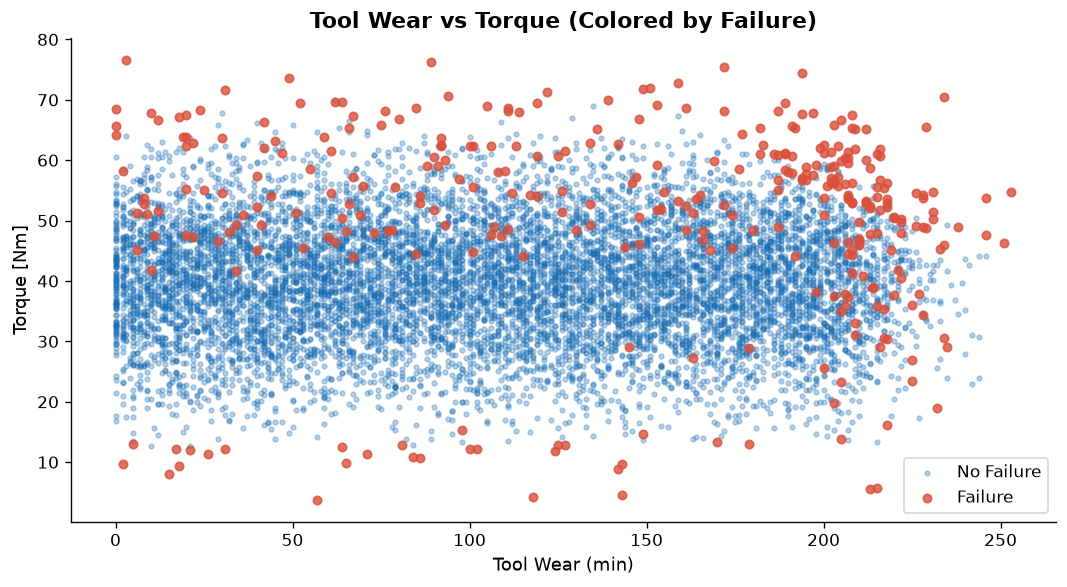

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(no_fail['Tool wear [min]'], no_fail['Torque [Nm]'],
           s=8, alpha=0.3, color=PALETTE[0], label='No Failure')
ax.scatter(failed['Tool wear [min]'], failed['Torque [Nm]'],
           s=25, alpha=0.8, color=PALETTE[1], label='Failure')
ax.set_title('Tool Wear vs Torque (Colored by Failure)', fontweight='bold')
ax.set_xlabel('Tool Wear (min)')
ax.set_ylabel('Torque [Nm]')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Failures (red) cluster at high torque values across all levels of tool wear. This suggests that excessive torque — whether from aggressive machining or worn tooling — is a stronger independent predictor of failure than wear level alone.

## 12. Failure Mode Deep Dive

Analysing each of the five binary failure modes against tool wear and other process parameters.

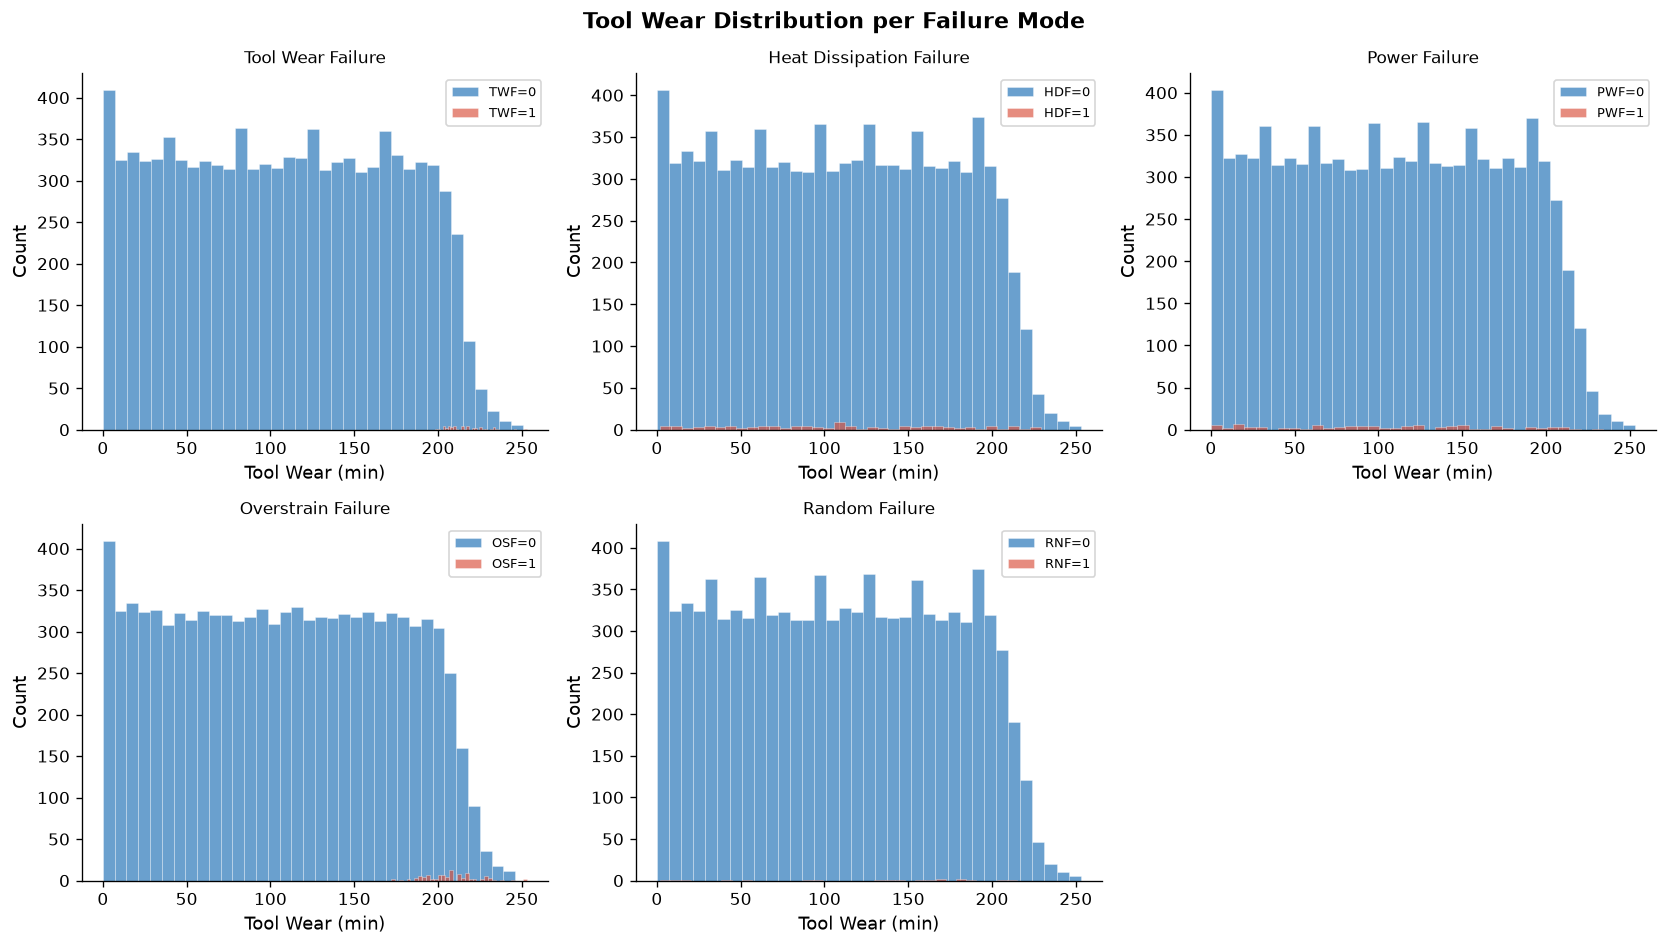

In [19]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
mode_full = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure',
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, mode in enumerate(failure_modes):
    for status, color in [(0, PALETTE[0]), (1, PALETTE[1])]:
        subset = df[df[mode] == status]['Tool wear [min]']
        label  = f'{mode}=0' if status == 0 else f'{mode}=1'
        axes[i].hist(subset, bins=35, alpha=0.65, color=color,
                     label=label, edgecolor='white', linewidth=0.3)
    axes[i].set_title(mode_full[mode], fontsize=10)
    axes[i].set_xlabel('Tool Wear (min)')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Tool Wear Distribution per Failure Mode',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Tool Wear Failure (TWF) concentrates at high wear values, as expected. Heat Dissipation and Power Failures appear throughout the wear range, suggesting temperature and power delivery are their primary drivers. Overstrain Failures tend towards higher wear combined with high torque.

In [20]:
# Mean feature values per failure mode
rows = []
for mode in failure_modes:
    sub  = df[df[mode] == 1]
    row  = {'Failure Mode': mode_full[mode], 'Count': len(sub)}
    for col in num_cols:
        short = col.split(' [')[0]
        row[f'Avg {short}'] = round(sub[col].mean(), 2)
    rows.append(row)

pd.DataFrame(rows).set_index('Failure Mode')

,Count,Avg Air temperature,Avg Process temperature,Avg Rotational speed,Avg Torque,Avg Tool wear
Failure Mode,,,,,,
Tool Wear Failure,46,300.30,310.17,1566.17,37.84,216.37
Heat Dissipation Failure,115,302.56,310.79,1337.26,53.17,107.19
Power Failure,95,300.08,309.95,1763.97,48.51,101.88
Overstrain Failure,98,300.04,310.07,1350.33,58.37,207.69
Random Failure,19,300.82,310.76,1485.00,43.67,124.47


## 13. Final Conclusions

---

### Dataset Quality

The AI4I 2020 dataset is synthetically generated and is clean — no missing values, no duplicates, and consistent data types. All features are within physically plausible ranges.

---

### Key Trends

1. **Class Imbalance:** Only ~3.4% of records represent failures. Real-world predictive maintenance datasets exhibit this pattern, which must be handled carefully in any downstream model.

2. **Temperature Coupling:** Air and Process temperatures are strongly correlated (r ≈ 0.88), meaning they carry largely redundant information. A temperature-difference feature may be more informative.

3. **Speed-Torque Inverse Relationship:** RPM and Torque share a strong negative correlation (r ≈ −0.88), consistent with constant-power mechanics. Failures cluster at the extremes of this relationship.

4. **Tool Wear:** Higher wear correlates with elevated failure rates, especially above ~200 min, but failures also occur at low wear levels due to other factors.

5. **Machine Type:** H-type machines have the highest failure rate percentage despite being the fewest, possibly because they are pushed harder operationally.

---

### Possible Causes of Machine Failure

- **Excessive torque** — the strongest single-feature predictor visible in scatter analysis.
- **Extreme rotational speeds** — failures concentrate outside the normal RPM range.
- **High tool wear** — particularly relevant for Tool Wear and Overstrain failures.
- **Thermal conditions** — Heat Dissipation Failure is the most common mode, tied to temperature elevation.

---

> *This analysis is entirely exploratory. No machine learning models or predictive algorithms were used. All findings are based on descriptive statistics and visualizations.*
